In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/schema-aware-split-features/schema_g1.jsonl
/kaggle/input/schema-aware-split-features/schema_g2.jsonl
/kaggle/input/schema-aware-split-features/schema_g3.jsonl
/kaggle/input/schema-aware-split-text/schema_g1.jsonl
/kaggle/input/schema-aware-split-text/schema_g2.jsonl
/kaggle/input/schema-aware-split-text/schema_g3.jsonl
/kaggle/input/transformer-roberta/pytorch/v1/1/transformer_best.pt
/kaggle/input/featureresmlp/pytorch/v1/1/feature_resmlp_best.pt
/kaggle/input/schema-model-results/sequence_metrics.csv
/kaggle/input/schema-model-results/sequence_metrics_t.csv
/kaggle/input/schema-model-results/feature_metrics.csv
/kaggle/input/attentivebilstm/pytorch/v1/1/bilstm_best.pt


# Schema Model Bias Variance Analysis

## Imports

In [2]:
import json
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    f1_score,
    confusion_matrix
)
from typing import Dict
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoTokenizer
from transformers import AutoConfig, AutoModel
import matplotlib.pyplot as plt
from collections import defaultdict

## Dataset

In [3]:
LABEL_MAP = {
    "normal": 0,
    "malicious": 1,
}

In [4]:
class FeatureDataset(Dataset):
    """
    Expected JSONL format per row:
    {
        "id": "...",
        "label": "normal" | "malicious",
        "features": { ... }
    }
    """

    def __init__(self, jsonl_path: str, feature_keys: list):
        self.feature_keys = feature_keys
        self.samples = []

        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                obj = json.loads(line)

                features = obj["features"]
                label = obj["label"]

                x = np.array(
                    [float(features[k]) for k in feature_keys],
                    dtype=np.float32
                )

                y = LABEL_MAP[label]
                self.samples.append((x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return torch.tensor(x), torch.tensor(y, dtype=torch.float32)
    

In [5]:
class TextDataset(Dataset):
    """
    Expected JSONL format per row:
    {
        "id": "...",
        "input_text": "...",
        "target_label": "normal" | "malicious",
        "meta": {...}
    }
    """

    def __init__(self, jsonl_path: str, tokenizer, max_len: int = 512):
        self.samples = []
        self.tokenizer = tokenizer
        self.max_len = max_len

        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                obj = json.loads(line)

                text = obj["input_text"]
                label = obj["target_label"]

                y = LABEL_MAP[label]
                self.samples.append((text, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        text, y = self.samples[idx]

        enc = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(y, dtype=torch.float32),
        }

In [11]:
# src/ml/models/feature_schema.py

"""
Central feature schema (Phase-1 complete).

Includes:
 - Structural AST statistics (from ast_extractor.js)
 - Depth metrics (from depth_calc.js)
 - Cost metrics (from cost_calc.js)
 - Text-level metrics (entropy, length, tokens)
 - Error flags

This list should only grow in later phases—never reorder or remove keys.
"""

FEATURE_KEYS = [
    # -----------------------------
    # AST / Structural Metrics
    # -----------------------------
    "num_fields",
    "num_fragments",
    "num_directives",
    "num_aliases",
    "num_operations",
    "num_mutations",
    "num_subscriptions",
    "num_variables",
    "num_arguments",
    "num_introspection_ops",

    # -----------------------------
    # Depth Metrics
    # -----------------------------
    "query_depth",
    "avg_depth",
    "branching_factor",
    "node_count",
    "num_nested_selections",

    # -----------------------------
    # Cost Metrics
    # -----------------------------
    "estimated_cost",
    "complexity_score",

    # -----------------------------
    # Text-Level Metrics
    # -----------------------------
    "entropy",
    "query_length",
    "num_tokens",

    # -----------------------------
    # Error Flags
    # -----------------------------
    "has_error",
]


def get_feature_keys():
    """Return stable ordered list of Phase-1 feature keys."""
    return FEATURE_KEYS.copy()

## DataLoaders

In [6]:
def build_feature_dataloaders(
    test_path: str,
    feature_keys: list,
    batch_size_test: int = 1024,
    num_workers: int = 0,
):
    test_ds = FeatureDataset(test_path, feature_keys)

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size_test,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )
    
    return test_loader


def build_text_dataloaders(
    test_path: str,
    tokenizer,
    max_len: int = 256,
    batch_size_test: int = 16,
    num_workers: int = 0,
):
    test_ds = TextDataset(test_path, tokenizer, max_len)

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size_test,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )
    
    return test_loader

## Metrics

In [7]:
def compute_classification_metrics(y_true: np.ndarray, y_pred_proba: np.ndarray, threshold: float = 0.5) -> Dict[str, float]:
    """
    y_true: shape (N,) values 0/1
    y_pred_proba: shape (N,) probabilities in [0,1]
    """
    y_true = y_true.astype(int)
    y_pred = (y_pred_proba >= threshold).astype(int)

    metrics = {}
    try:
        metrics["accuracy"] = float(accuracy_score(y_true, y_pred))
        metrics["precision"] = float(precision_score(y_true, y_pred, zero_division=0))
        metrics["recall"] = float(recall_score(y_true, y_pred, zero_division=0))
        metrics["f1"] = float(f1_score(y_true, y_pred, zero_division=0))
    except Exception:
        metrics["accuracy"] = metrics["precision"] = metrics["recall"] = metrics["f1"] = 0.0

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_pred_proba))
    except Exception:
        metrics["roc_auc"] = float("nan")

    # FPR at high threshold
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    metrics["fpr"] = float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0
    metrics["tpr"] = float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0

    return metrics

## Models

### FeatureResMLP

In [8]:
class ResidualBlock(nn.Module):
    """
    One residual block for tabular ResNet-MLP:
    x -> LN -> Linear -> GELU -> Dropout -> Linear -> Dropout -> +x
    """
    def __init__(self, dim: int, dropout: float = 0.2):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        h = self.norm(x)
        h = self.fc1(h)
        h = F.gelu(h)
        h = self.dropout(h)
        h = self.fc2(h)
        h = self.dropout(h)
        return residual + h


class FeatureResMLP(nn.Module):
    """
    Strong residual MLP for tabular GraphQL feature vectors.

    Input:
        x: (batch_size, input_dim)
    Output:
        logit: (batch_size,)   # use BCEWithLogitsLoss
    """

    def __init__(
        self,
        input_dim: int,
        width: int = 128,
        num_blocks: int = 4,
        dropout: float = 0.2,
    ):
        super().__init__()

        # Input projection
        self.input_proj = nn.Linear(input_dim, width)

        # Residual trunk
        self.blocks = nn.ModuleList([
            ResidualBlock(width, dropout=dropout)
            for _ in range(num_blocks)
        ])

        # Output head
        self.norm_out = nn.LayerNorm(width)
        self.head = nn.Sequential(
            nn.Linear(width, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),   # binary logit
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        x: FloatTensor of shape (batch_size, input_dim)
        returns: logits (batch_size,)
        """
        h = self.input_proj(x)
        for block in self.blocks:
            h = block(h)
        h = self.norm_out(h)
        logit = self.head(h).squeeze(-1)
        return logit

### Attention based Bi-LSTM

In [9]:
class AttentiveBiLSTM(nn.Module):
    """
    Strong text classifier:
    Embedding -> BiLSTM -> Multi-Head Self-Attention -> Masked Mean Pool -> MLP Head

    Input:
        input_ids: (batch, seq_len)
        attention_mask: (batch, seq_len) with 1 for tokens, 0 for padding

    Output:
        logit: (batch,)  # binary logit for BCEWithLogitsLoss
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 256,
        hidden_size: int = 256,
        num_layers: int = 2,
        num_heads: int = 4,
        dropout: float = 0.3,
        pad_idx: int = 0,
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size * 2,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.norm = nn.LayerNorm(hidden_size * 2)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, input_ids, attention_mask=None):
        """
        input_ids: LongTensor (batch, seq_len)
        attention_mask: LongTensor (batch, seq_len), 1 = keep, 0 = pad
        """

        # (batch, seq_len, embed_dim)
        x = self.embedding(input_ids)

        # (batch, seq_len, 2 * hidden)
        lstm_out, _ = self.lstm(x)

        # Convert to key padding mask: True = ignore
        if attention_mask is not None:
            key_padding_mask = attention_mask == 0
        else:
            key_padding_mask = None

        # Self-attention
        attn_out, _ = self.attention(
            lstm_out, lstm_out, lstm_out,
            key_padding_mask=key_padding_mask
        )

        # Masked mean pooling
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).float()
            attn_out = attn_out * mask
            pooled = attn_out.sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
        else:
            pooled = attn_out.mean(dim=1)

        pooled = self.norm(pooled)

        # Final logit
        logit = self.classifier(pooled).squeeze(-1)
        return logit

### Pretrained Transformer

In [10]:
class SOTATransformerClassifier(nn.Module):
    """
    Pretrained Transformer-based binary classifier.

    - Uses a strong encoder (e.g. roberta-base or deberta-v3-base)
    - Adds a small MLP head on top of the pooled representation
    - Outputs logits for BCEWithLogitsLoss

    Forward:
        input_ids: LongTensor (batch, seq_len)
        attention_mask: LongTensor (batch, seq_len) with 1 for tokens, 0 for padding

    Returns:
        logit: FloatTensor (batch,)
    """

    def __init__(
        self,
        model_name: str = "roberta-base",
        dropout: float = 0.2,
        freeze_encoder: bool = False,
    ):
        super().__init__()

        # Load config and backbone
        self.config = AutoConfig.from_pretrained(model_name)
        self.transformer = AutoModel.from_pretrained(model_name, config=self.config)

        hidden_size = self.config.hidden_size

        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

        # Optionally freeze encoder (e.g. for ablations / low-resource)
        if freeze_encoder:
            for param in self.transformer.parameters():
                param.requires_grad = False

        self._init_head()

    def _init_head(self):
        # Initialize only the head; encoder stays as loaded
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, input_ids, attention_mask):
        """
        input_ids: (batch, seq_len)
        attention_mask: (batch, seq_len)

        Returns:
            logits: (batch,)
        """
        outputs = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        # For many models:
        # - If pooler_output exists -> use it
        # - Else -> use [CLS] token representation
        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            pooled = outputs.pooler_output  # (batch, hidden)
        else:
            # last_hidden_state: (batch, seq_len, hidden)
            pooled = outputs.last_hidden_state[:, 0, :]  # CLS

        logits = self.classifier(pooled).squeeze(-1)
        return logits

## Evaluate Model

In [42]:
def evaluate_model(
    model,
    dataloader,
    checkpoint_path,
    device="cuda" if torch.cuda.is_available() else "cpu",
):
    # Load model
    model = model.to(device)
    state = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state)
    model.eval()

    all_logits = []
    all_labels = []

    # Inference with tqdm progress bar
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", unit="batch"):
            # Tabular model (list/tuple batch)
            if isinstance(batch, (list, tuple)):
                x, y = batch
                x = x.to(device)
                y = y.to(device)
                logits = model(x)
            # Text model (dict batch)
            elif isinstance(batch, dict):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                y = batch["labels"].to(device)
                logits = model(input_ids, attention_mask)
            else:
                raise TypeError(f"Unknown batch type: {type(batch)}")

            logits = logits.squeeze(-1)
            all_logits.append(logits.cpu())
            all_labels.append(y.cpu())

    # Concatenate all logits and labels
    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    # Convert logits to probabilities using sigmoid
    y_pred_proba = torch.sigmoid(all_logits).cpu().numpy()

    # Compute metrics
    metrics = compute_classification_metrics(
        y_true=all_labels.numpy(),
        y_pred_proba=y_pred_proba,
        threshold=0.5,
    )

    return metrics


## Tests

### Feature ResMLP

In [43]:
schema1_test_dataloader = build_feature_dataloaders(
    test_path="/kaggle/input/schema-aware-split-features/schema_g1.jsonl" ,
    feature_keys=FEATURE_KEYS
)
schema2_test_dataloader = build_feature_dataloaders(
    test_path="/kaggle/input/schema-aware-split-features/schema_g2.jsonl" ,
    feature_keys=FEATURE_KEYS
)
schema3_test_dataloader = build_feature_dataloaders(
    test_path="/kaggle/input/schema-aware-split-features/schema_g3.jsonl" ,
    feature_keys=FEATURE_KEYS
)

s1_metrics = evaluate_model(
    model=FeatureResMLP(input_dim=len(FEATURE_KEYS)),
    dataloader=schema1_test_dataloader,
    checkpoint_path="/kaggle/input/featureresmlp/pytorch/v1/1/feature_resmlp_best.pt",
)

print(s1_metrics)

s2_metrics = evaluate_model(
    model=FeatureResMLP(input_dim=len(FEATURE_KEYS)),
    dataloader=schema2_test_dataloader,
    checkpoint_path="/kaggle/input/featureresmlp/pytorch/v1/1/feature_resmlp_best.pt",
)

print(s2_metrics)

s3_metrics = evaluate_model(
    model=FeatureResMLP(input_dim=len(FEATURE_KEYS)),
    dataloader=schema3_test_dataloader,
    checkpoint_path="/kaggle/input/featureresmlp/pytorch/v1/1/feature_resmlp_best.pt",
)

print(s3_metrics)

Evaluating: 100%|██████████| 11/11 [00:00<00:00, 84.45batch/s]


{'accuracy': 0.9773462783171522, 'precision': 0.9956072351421189, 'recall': 0.9441313403577555, 'f1': 0.9691862658785059, 'roc_auc': 0.9922436418393292, 'fpr': 0.0025245025245025244, 'tpr': 0.9441313403577555}


Evaluating: 100%|██████████| 11/11 [00:00<00:00, 83.53batch/s]


{'accuracy': 0.9628605658464657, 'precision': 0.9842824014429271, 'recall': 0.9178279673234022, 'f1': 0.9498943180405321, 'roc_auc': 0.9855070389256059, 'fpr': 0.009119449843025863, 'tpr': 0.9178279673234022}


Evaluating: 100%|██████████| 11/11 [00:00<00:00, 30.13batch/s]

{'accuracy': 0.9849985847721483, 'precision': 0.997128687026886, 'recall': 0.9627016129032258, 'f1': 0.97961277086806, 'roc_auc': 0.9945658048280073, 'fpr': 0.0016588749811491479, 'tpr': 0.9627016129032258}


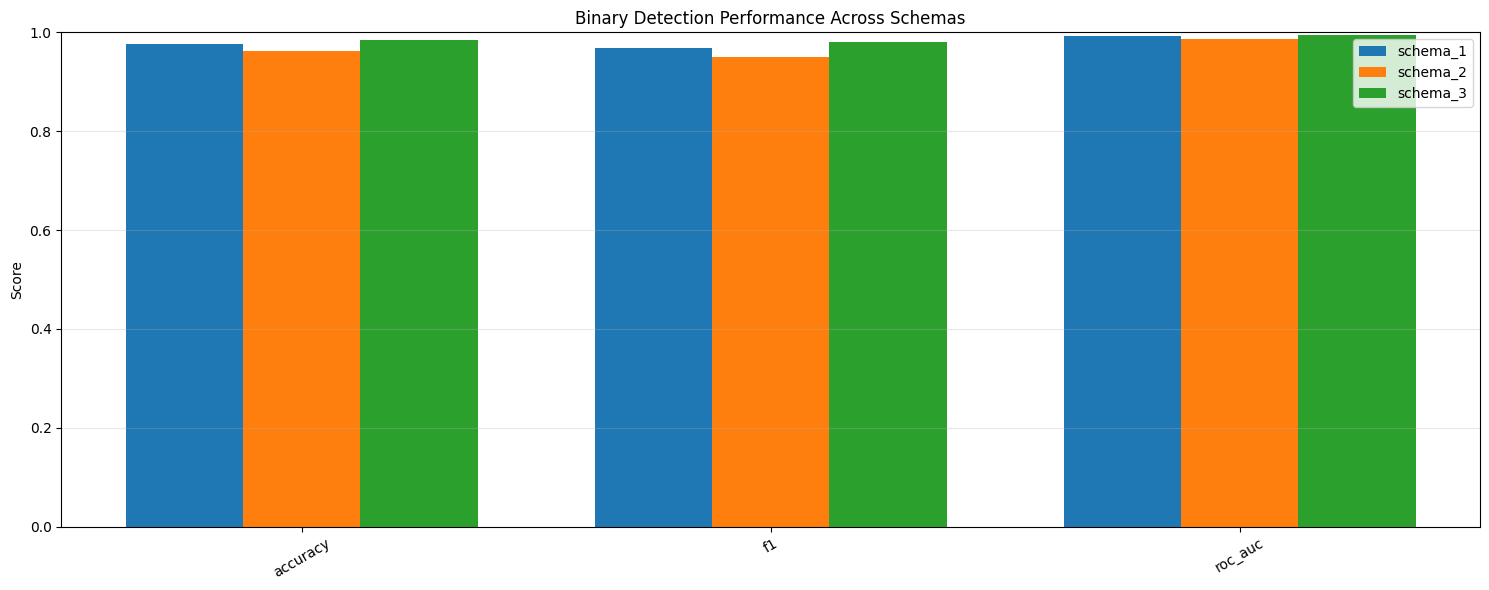

In [36]:
def plot_metric_bars(metrics_dicts, labels, metric_names):
    """
    metrics_dicts: list of dicts
    labels: list of str (schema_g1, schema_g2, ...)
    metric_names: list of metric keys to plot
    """
    x = np.arange(len(metric_names))
    width = 0.25

    plt.figure(figsize=(15, 6))

    for i, (metrics, label) in enumerate(zip(metrics_dicts, labels)):
        values = [metrics[m] for m in metric_names]
        plt.bar(x + i * width, values, width, label=label)

    plt.xticks(x + width, metric_names, rotation=30)
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title("Binary Detection Performance Across Schemas")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_metric_bars(
    metrics_dicts=[s1_metrics, s2_metrics, s3_metrics],
    labels=["schema_1", "schema_2", "schema_3"],
    metric_names=["accuracy", "f1", "roc_auc"]
)

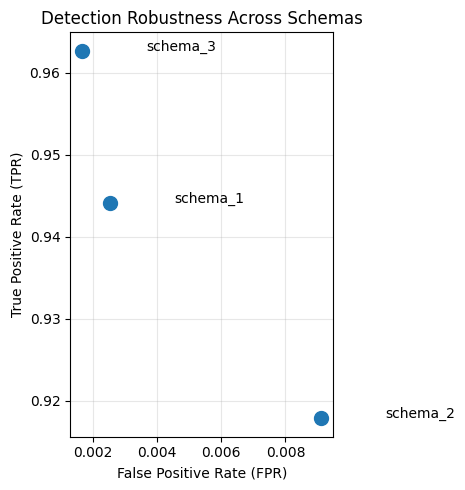

In [37]:
def plot_fpr_tpr(metrics_dicts, labels):
    fpr = [m["fpr"] for m in metrics_dicts]
    tpr = [m["tpr"] for m in metrics_dicts]

    plt.figure(figsize=(5, 5))
    plt.scatter(fpr, tpr, s=100)

    for i, label in enumerate(labels):
        plt.text(fpr[i] + 0.002, tpr[i], label)

    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("Detection Robustness Across Schemas")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_fpr_tpr(
    metrics_dicts=[s1_metrics, s2_metrics, s3_metrics],
    labels=["schema_1", "schema_2", "schema_3"]
)

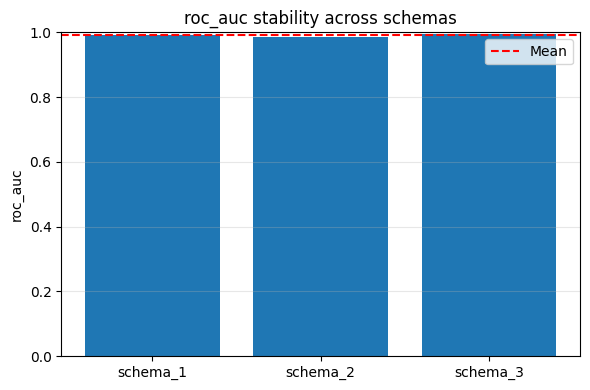

In [38]:
def plot_metric_variance(metrics_dicts, labels, metric):
    values = [m[metric] for m in metrics_dicts]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, values)
    plt.axhline(np.mean(values), linestyle="--", color="red", label="Mean")

    plt.ylim(0, 1.0)
    plt.ylabel(metric)
    plt.title(f"{metric} stability across schemas")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_metric_variance(
    metrics_dicts=[s1_metrics, s2_metrics, s3_metrics],
    labels=["schema_1", "schema_2", "schema_3"],
    metric="roc_auc"
)


In [39]:
def metrics_to_table(metrics_dicts, labels):
    df = pd.DataFrame(metrics_dicts, index=labels)
    return df[["accuracy", "precision", "recall", "f1", "roc_auc", "fpr", "tpr"]]

df = metrics_to_table(
    metrics_dicts=[s1_metrics, s2_metrics, s3_metrics],
    labels=["schema_1", "schema_2", "schema_3"],
)

In [40]:
df.to_csv("feature_metrics.csv")

### Attention based Bi-LSTM

In [44]:
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
pad_idx = tokenizer.pad_token_id

schema1_test_dataloader_seq = build_text_dataloaders(
    test_path="/kaggle/input/schema-aware-split-text/schema_g1.jsonl" ,
    tokenizer = tokenizer
)
schema2_test_dataloader_seq = build_text_dataloaders(
    test_path="/kaggle/input/schema-aware-split-text/schema_g2.jsonl" ,
    tokenizer=tokenizer
)
schema3_test_dataloader_seq = build_text_dataloaders(
    test_path="/kaggle/input/schema-aware-split-text/schema_g3.jsonl" ,
    tokenizer=tokenizer
)

s1_metrics_seq = evaluate_model(
    model = AttentiveBiLSTM(vocab_size=tokenizer.vocab_size,pad_idx=pad_idx),
    dataloader=schema1_test_dataloader_seq,
    checkpoint_path="/kaggle/input/attentivebilstm/pytorch/v1/1/bilstm_best.pt",
)

print(s1_metrics_seq)

s2_metrics_seq = evaluate_model(
    model = AttentiveBiLSTM(vocab_size=tokenizer.vocab_size,pad_idx=pad_idx),
    dataloader=schema2_test_dataloader_seq,
    checkpoint_path="/kaggle/input/attentivebilstm/pytorch/v1/1/bilstm_best.pt",
)

print(s2_metrics_seq)

s3_metrics_seq = evaluate_model(
    model = AttentiveBiLSTM(vocab_size=tokenizer.vocab_size,pad_idx=pad_idx),
    dataloader=schema3_test_dataloader_seq,
    checkpoint_path="/kaggle/input/attentivebilstm/pytorch/v1/1/bilstm_best.pt",
)

print(s3_metrics_seq)

Evaluating: 100%|██████████| 339/339 [01:37<00:00,  3.49batch/s]


{'accuracy': 0.988274397562552, 'precision': 0.9982587064676617, 'recall': 0.970965400435519, 'f1': 0.9844229118116031, 'roc_auc': 0.9966394156031858, 'fpr': 0.0010450880859958196, 'tpr': 0.970965400435519}


Evaluating: 100%|██████████| 342/342 [02:39<00:00,  2.14batch/s]


{'accuracy': 0.9873707330465818, 'precision': 0.998025666337611, 'recall': 0.9688548155246766, 'f1': 0.9832239241429613, 'roc_auc': 0.9967620914334263, 'fpr': 0.0011846586702206428, 'tpr': 0.9688548155246766}


Evaluating: 100%|██████████| 329/329 [00:28<00:00, 11.39batch/s]

{'accuracy': 0.9952412677262777, 'precision': 0.9989785495403473, 'recall': 0.988377968671046, 'f1': 0.9936499872999746, 'roc_auc': 0.9988396255043508, 'fpr': 0.0006107802717972209, 'tpr': 0.988377968671046}


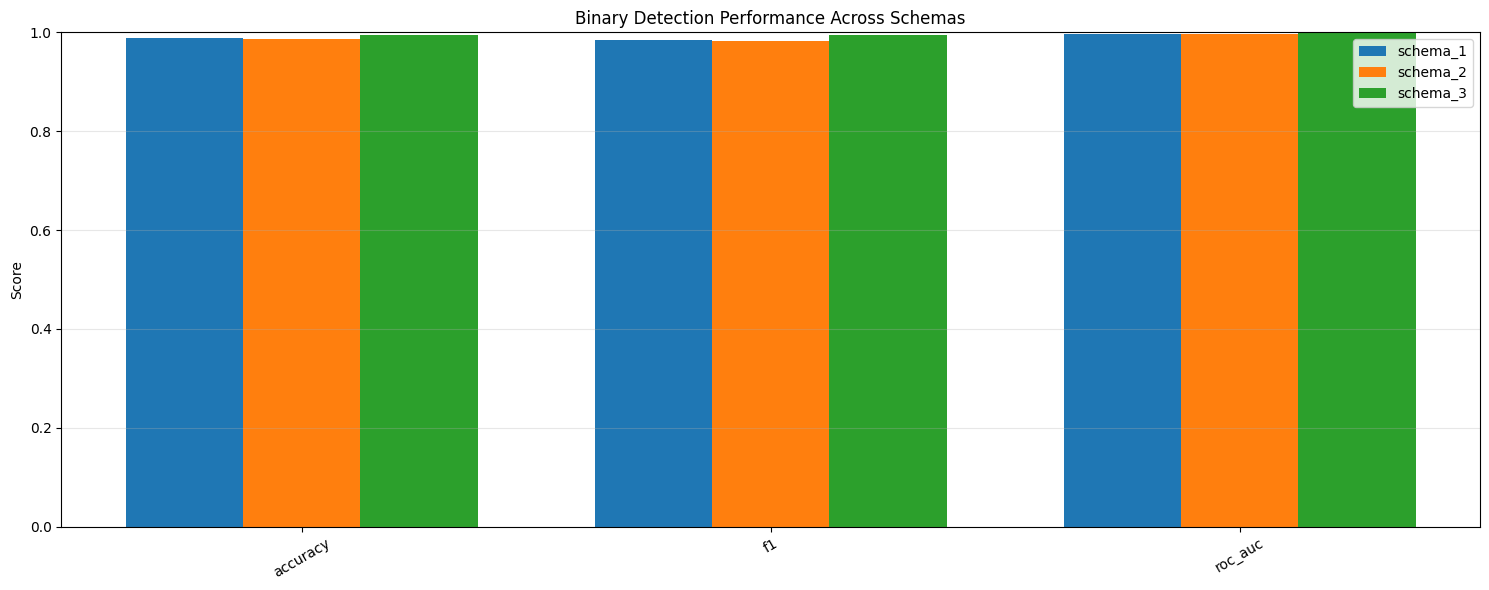

In [45]:
plot_metric_bars(
    metrics_dicts=[s1_metrics_seq, s2_metrics_seq, s3_metrics_seq],
    labels=["schema_1", "schema_2", "schema_3"],
    metric_names=["accuracy", "f1", "roc_auc"]
)

/tmp/ipykernel_55/1499275573.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


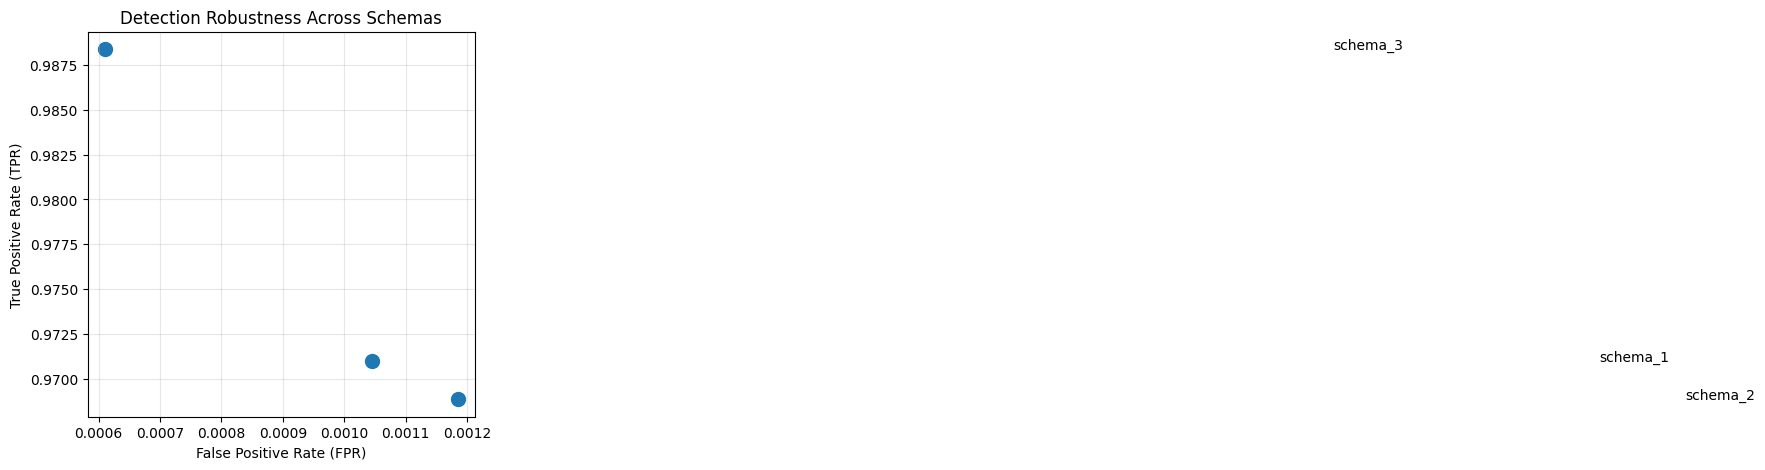

In [52]:
plot_fpr_tpr(
    metrics_dicts=[s1_metrics_seq, s2_metrics_seq, s3_metrics_seq],
    labels=["schema_1", "schema_2", "schema_3"]
)

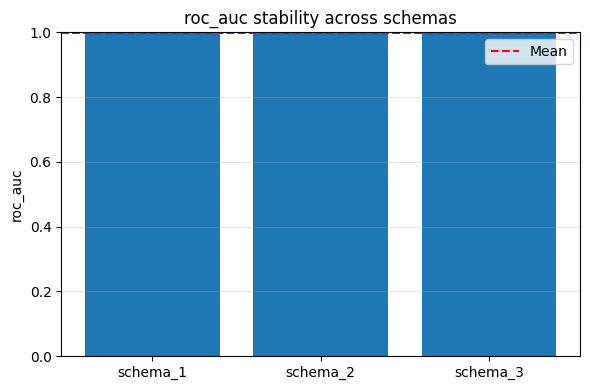

In [47]:
plot_metric_variance(
    metrics_dicts=[s1_metrics_seq, s2_metrics_seq, s3_metrics_seq],
    labels=["schema_1", "schema_2", "schema_3"],
    metric="roc_auc"
)

In [48]:
df_seq = metrics_to_table(
    metrics_dicts=[s1_metrics_seq, s2_metrics_seq, s3_metrics_seq],
    labels=["schema_1", "schema_2", "schema_3"],
)
df_seq.to_csv("sequence_metrics.csv")

### Transformer

In [51]:
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
pad_idx = tokenizer.pad_token_id

schema1_test_dataloader_seq = build_text_dataloaders(
    test_path="/kaggle/input/schema-aware-split-text/schema_g1.jsonl" ,
    tokenizer = tokenizer,
)
schema2_test_dataloader_seq = build_text_dataloaders(
    test_path="/kaggle/input/schema-aware-split-text/schema_g2.jsonl" ,
    tokenizer=tokenizer
)
schema3_test_dataloader_seq = build_text_dataloaders(
    test_path="/kaggle/input/schema-aware-split-text/schema_g3.jsonl" ,
    tokenizer=tokenizer
)

s1_metrics_seqt = evaluate_model(
    model = SOTATransformerClassifier(model_name=str(MODEL_NAME)),
    dataloader=schema1_test_dataloader_seq,
    checkpoint_path="/kaggle/input/transformer-roberta/pytorch/v1/1/transformer_best.pt",
)

print(s1_metrics_seqt)

s2_metrics_seqt = evaluate_model(
    model = SOTATransformerClassifier(model_name=str(MODEL_NAME)),
    dataloader=schema2_test_dataloader_seq,
    checkpoint_path="/kaggle/input/transformer-roberta/pytorch/v1/1/transformer_best.pt",
)

print(s2_metrics_seqt)

s3_metrics_seqt = evaluate_model(
    model = SOTATransformerClassifier(model_name=str(MODEL_NAME)),
    dataloader=schema3_test_dataloader_seq,
    checkpoint_path="/kaggle/input/transformer-roberta/pytorch/v1/1/transformer_best.pt",
)

print(s3_metrics_seqt)

2025-12-26 10:02:36.586057: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766743356.769789      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766743356.823299      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766743357.255968      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766743357.256009      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766743357.256011      55 computation_placer.cc:177] computation placer alr

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Evaluating: 100%|█████████▉| 338/339 [06:10<00:01,  1.09s/batch]Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Evaluating: 100%|██████████| 342/342 [06:57<00:00,  1.22s/batch]


{'accuracy': 0.9838015923858333, 'precision': 0.9889894788353315, 'recall': 0.9683756588404409, 'f1': 0.978574022515434, 'roc_auc': 0.9952735163012254, 'fpr': 0.006663705019991115, 'tpr': 0.9683756588404409}


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Evaluating: 100%|██████████| 329/329 [05:17<00:00,  1.03batch/s]

{'accuracy': 0.9849624060150376, 'precision': 0.972636815920398, 'recall': 0.9878726629610914, 'f1': 0.9801955377287541, 'roc_auc': 0.9974149087637323, 'fpr': 0.016796457474423578, 'tpr': 0.9878726629610914}


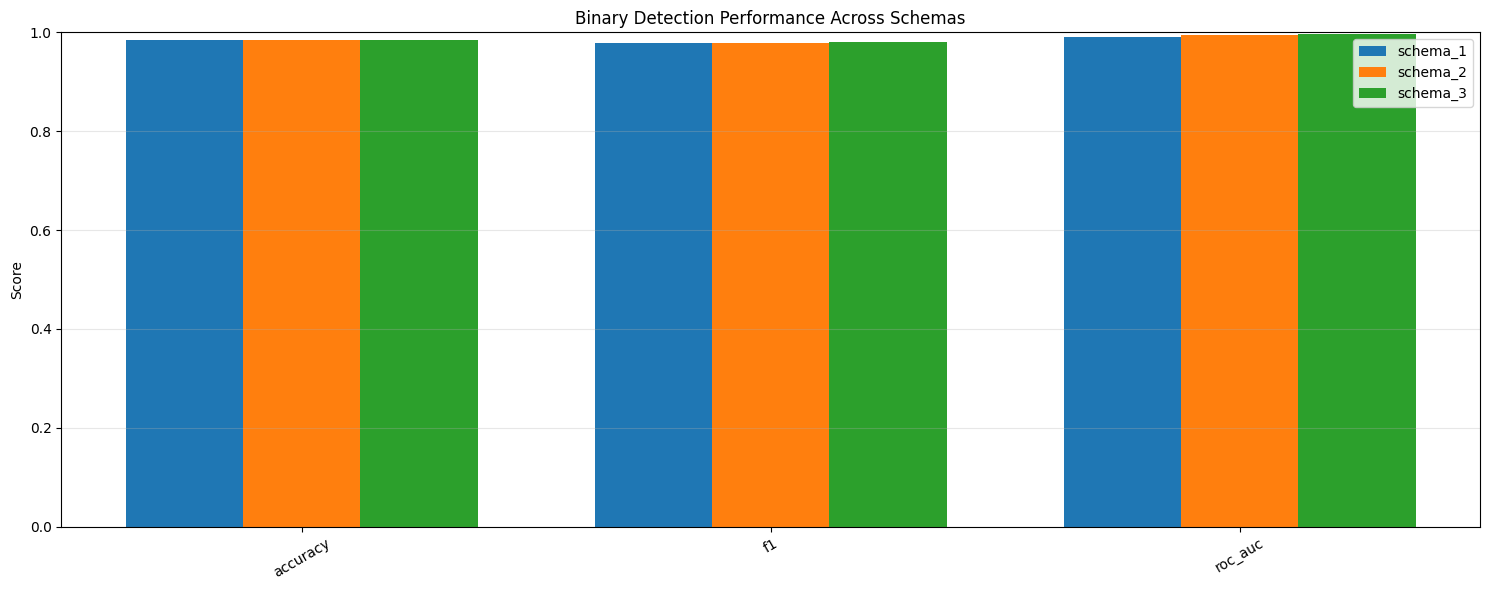

In [53]:
plot_metric_bars(
    metrics_dicts=[s1_metrics_seqt, s2_metrics_seqt, s3_metrics_seqt],
    labels=["schema_1", "schema_2", "schema_3"],
    metric_names=["accuracy", "f1", "roc_auc"]
)

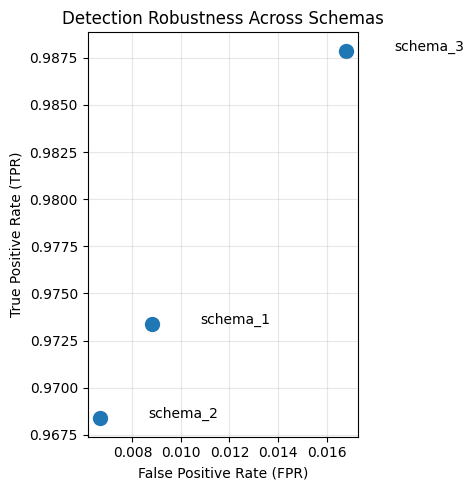

In [54]:
plot_fpr_tpr(
    metrics_dicts=[s1_metrics_seqt, s2_metrics_seqt, s3_metrics_seqt],
    labels=["schema_1", "schema_2", "schema_3"]
)

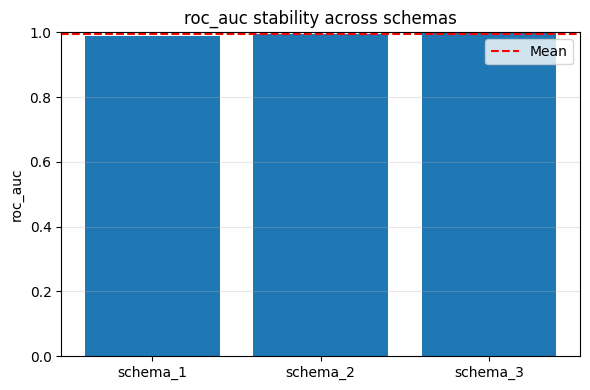

In [55]:
plot_metric_variance(
    metrics_dicts=[s1_metrics_seqt, s2_metrics_seqt, s3_metrics_seqt],
    labels=["schema_1", "schema_2", "schema_3"],
    metric="roc_auc"
)

In [56]:
df_seq = metrics_to_table(
    metrics_dicts=[s1_metrics_seqt, s2_metrics_seqt, s3_metrics_seqt],
    labels=["schema_1", "schema_2", "schema_3"],
)
df_seq.to_csv("sequence_metrics_t.csv")

## Reports

In [3]:
# Update paths if needed
feature_csv = "/kaggle/input/schema-model-results/feature_metrics.csv"
bilstm_csv = "/kaggle/input/schema-model-results/sequence_metrics.csv"
transformer_csv = "/kaggle/input/schema-model-results/sequence_metrics_t.csv"

dfs = {
    "FeatureResMLP": pd.read_csv(feature_csv, index_col=0),
    "BiLSTM": pd.read_csv(bilstm_csv, index_col=0),
    "Transformer": pd.read_csv(transformer_csv, index_col=0),
}

In [4]:
METRICS = ["accuracy", "f1", "roc_auc", "fpr"]

rows = []

for model_name, df in dfs.items():
    for metric in METRICS:
        values = df[metric].values
        rows.append({
            "model": model_name,
            "metric": metric,
            "mean": float(np.mean(values)),
            "std": float(np.std(values)),
            "min": float(np.min(values)),
            "max": float(np.max(values)),
        })

d1b_stats = pd.DataFrame(rows)
d1b_stats

,model,metric,mean,std,min,max
0,FeatureResMLP,accuracy,0.975068,0.009180,0.962861,0.984999
1,FeatureResMLP,f1,0.966231,0.012311,0.949894,0.979613
2,FeatureResMLP,roc_auc,0.990772,0.003842,0.985507,0.994566
3,FeatureResMLP,fpr,0.004434,0.003332,0.001659,0.009119
4,BiLSTM,accuracy,0.990295,0.003517,0.987371,0.995241
5,BiLSTM,f1,0.987099,0.004658,0.983224,0.993650
6,BiLSTM,roc_auc,0.997414,0.001010,0.996639,0.998840
7,BiLSTM,fpr,0.000947,0.000244,0.000611,0.001185
8,Transformer,accuracy,0.984387,0.000474,0.983802,0.984962
9,Transformer,f1,0.979399,0.000662,0.978574,0.980196


In [5]:
summary_table = d1b_stats.pivot(
    index="model",
    columns="metric",
    values=["mean", "std"]
)

summary_table

mean                                     std            \
metric         accuracy        f1       fpr   roc_auc  accuracy        f1   
model                                                                       
BiLSTM         0.990295  0.987099  0.000947  0.997414  0.003517  0.004658   
FeatureResMLP  0.975068  0.966231  0.004434  0.990772  0.009180  0.012311   
Transformer    0.984387  0.979399  0.010756  0.994089  0.000474  0.000662   

                                   
metric              fpr   roc_auc  
model                              
BiLSTM         0.000244  0.001010  
FeatureResMLP  0.003332  0.003842  
Transformer    0.004360  0.003307

In [6]:
summary_table.to_csv("schema_variance_table.csv")

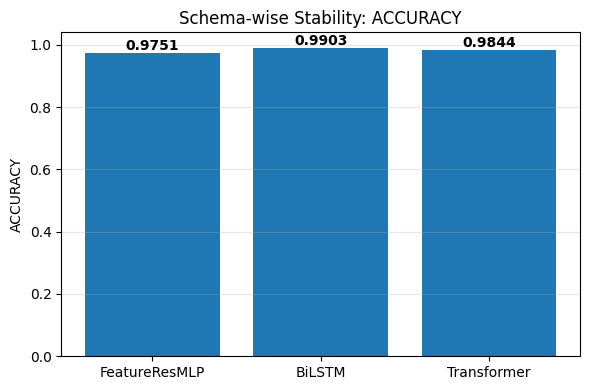

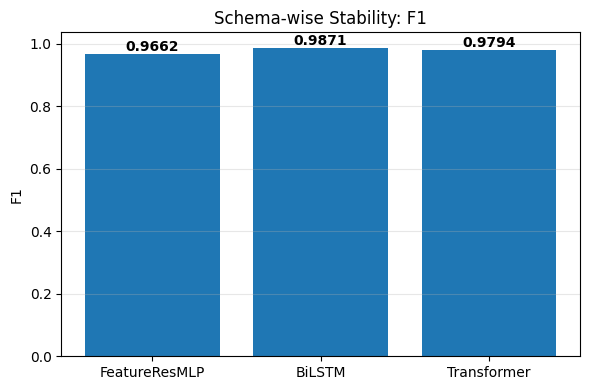

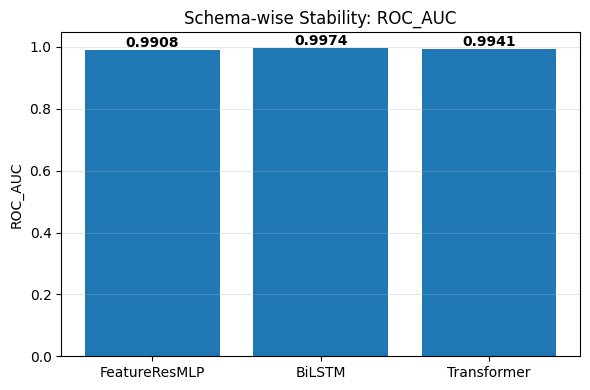

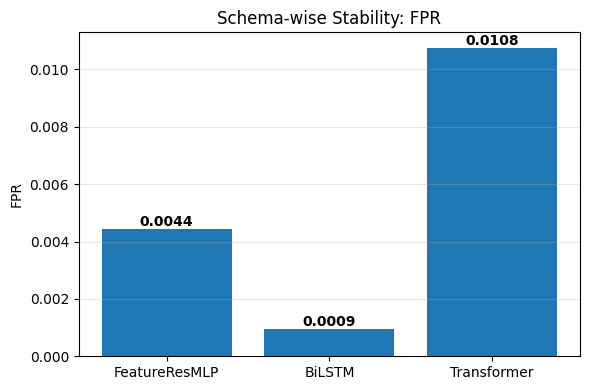

In [10]:
import matplotlib.pyplot as plt

for metric in METRICS:
    subset = d1b_stats[d1b_stats["metric"] == metric]

    plt.figure(figsize=(6,4))
    bars = plt.bar(
        subset["model"],
        subset["mean"],
    )

    plt.ylabel(metric.upper())
    plt.title(f"Schema-wise Stability: {metric.upper()}")
    plt.grid(axis="y", alpha=0.3)

    # ---- value labels on bars ----
    for bar, val in zip(bars, subset["mean"]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.4f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    plt.tight_layout()
    plt.show()

In [8]:
variance_score = (
    d1b_stats[d1b_stats["metric"].isin(["accuracy", "f1", "roc_auc"])]
    .groupby("model")["std"]
    .mean()
    .sort_values()
)

variance_score

model
Transformer      0.001481
BiLSTM           0.003061
FeatureResMLP    0.008444
Name: std, dtype: float64